In [195]:
from accelforge import Spec, examples
from pathlib import Path

In [196]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

# Attention Baseline (plain workload to pipelining)

In [197]:
# Load architecture, workload, and mapping
spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention.yaml"
)
# spec.workload

In [198]:
# Run analysis
results = spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/3 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running QK:   0%|  | 0/3 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running QK:  33%|▎| 1/3 [00:00<00:00,  9.
Getting energy, latency, and leak power for components running QK_softmax:  33%|▎| 1/3 [00:00<00
Getting energy, latency, and leak power for components running AV:  33%|▎| 1/3 [00:00<00:00,  9.
Getting energy, latency, and leak power for components running AV: 100%|█| 3/3 [00:00<00:00, 14.

Generating pmapping templates for compute ScalarUnit Einsum AV: 0it [00:00, ?it/s], ?it/s]?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 26it [00:00, 68.64it/s]
Generating pmapping templates for compute MXU Einsum QK_softmax: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum QK_

Einsum QK has 108 pmapping jobs:
	0	[Q in MainMemory] [K in MainMemory] [QK in GlobalBuffer] T-b  T-e  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in MxuBuffer] T-e  MXU computes QK
	1	[Q in MainMemory] [K in MainMemory] [QK in GlobalBuffer] T-b  T-h  T-m  T-m_full  S-reuse_weight2-m  S-reuse_weight1-m  [QK in MxuBuffer] T-e  [Q in MxuBuffer] T-m_full  MXU computes QK
	2	[Q in MainMemory] [K in MainMemory] [K in GlobalBuffer] [QK in GlobalBuffer] T-b  T-e  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in MxuBuffer] T-e  MXU computes QK
	3	[Q in MainMemory] [K in MainMemory] [K in GlobalBuffer] [QK in GlobalBuffer] T-b  T-h  T-m  T-m_full  S-reuse_weight2-m  S-reuse_weight1-m  [QK in MxuBuffer] T-e  [Q in MxuBuffer] T-m_full  MXU computes QK
	4	[Q in MainMemory] [K in MainMemory] [QK in GlobalBuffer] T-b  T-e  T-h  T-m_full  [K in GlobalBuffer] T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in


Grouping pmappings for AV: 100%|██████████████████████████████████| 1/1 [00:00<00:00,  4.65it/s]

Compressing pmappings: 100%|█████████████████████████████████████| 3/3 [00:00<00:00, 107.02it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal



Dirty pruning pmappings: 100%|███████████████████████████████████| 3/3 [00:00<00:00, 121.67it/s]


...


Dirty pruning pmappings: 100%|███████████████████████████████████| 3/3 [00:00<00:00, 100.09it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 3 -> 3 (100.00% kept) pmappings
Not tracking GlobalBuffer because it is never reserved for multiple pmappings.
Not tracking GlobalBuffer because its size is enough for the sum of all reservations (0.00% of the total)


Final consolidate: 100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 163.88it/s]


Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


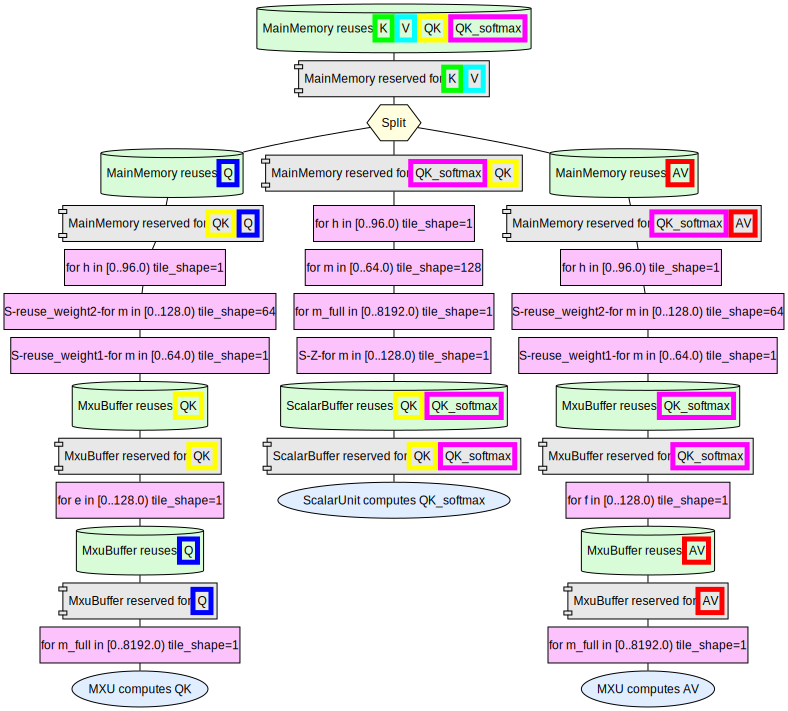

In [199]:
results

In [200]:
print("Total Cycles: ", get_cycles(results))
print("Total Energy: ", get_energy(results))
print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
print("VPU: ", get_component_energy(results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
print("MXU: ", get_component_energy(results, 'MXU'))

Total Cycles:  0.21272480115294456
Total Energy:  12.118247810288478
MainMemory:  1.4719389474634819
GlobalBuffer:  0.0

ScalarBuffer:  0.05586893467517666
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  10.451901463050046
MXU:  0.138538465099776


# Baseline With Separate Workloads (assert same results)

In [201]:
QK_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention_QK.yaml"
)
QK_results = QK_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running QK:   0%|  | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running QK: 100%|█| 1/1 [00:00<00:00,  8.
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK: 2it [00:00, 15.73it/s]
Generating pmapping templates for compute MXU Einsum QK: 5it [00:00, 20.00it/s]
Generating pmapping templates for compute MXU Einsum QK: 7it [00:00, 16.05it/s]
Generating pmapping templates for compute MXU Einsum QK: 10it [00:00, 19.31it/s]
Generating pmapping templates for compute MXU Einsum QK: 14it [00:00, 22.73it/s]
Generating pmapping templates for compute MXU Ein

Einsum QK has 64 pmapping jobs:
	0	[QK in MainMemory] [Q in MainMemory] [K in MainMemory] T-b  T-e  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in MxuBuffer] T-e  MXU computes QK
	1	[QK in MainMemory] [Q in MainMemory] [K in MainMemory] T-b  T-h  T-m  T-m_full  S-reuse_weight2-m  S-reuse_weight1-m  [QK in MxuBuffer] T-e  [Q in MxuBuffer] T-m_full  MXU computes QK
	2	[QK in MainMemory] [Q in MainMemory] [K in MainMemory] T-b  T-e  T-h  T-m_full  [K in GlobalBuffer] T-m  S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in MxuBuffer] T-e  MXU computes QK
	3	[QK in MainMemory] [Q in MainMemory] [K in MainMemory] T-b  T-e  T-h  T-m_full  [K in GlobalBuffer] T-m  S-reuse_weight2-m  S-reuse_weight1-m  [QK in MxuBuffer] T-e  [Q in MxuBuffer] T-m_full  MXU computes QK
	4	[QK in MainMemory] [Q in MainMemory] [K in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] S-reuse_weight2-m  S-reuse_weight1-m  [Q in MxuBuffer] T-m_full  [QK in MxuBu


Compressing pmappings: 100%|██████████████████████████████████████| 1/1 [00:00<00:00, 42.23it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 211.81it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=5.66e+00
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 237.19it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 682.00it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [202]:
QK_softmax_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention_QK_softmax.yaml"
)
QK_softmax_results = QK_softmax_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running QK_softmax:   0%| | 0/1 [00:00<?,
Getting energy, latency, and leak power for components running QK_softmax: 100%|█| 1/1 [00:00<00
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 1it [00:00,  6.35it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 5it [00:00, 15.70it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_softmax: 10it [00:00, 20.50it/s][A

Generating pmapping templates for compute MXU Einsum QK_softmax: 0it [00:00, ?it/s]

Generating pmapping templates for compute VPU Einsum QK_softmax: 0it [00:00, ?it/s]
Generating jobs: 100%|████████████████████████████████████████

Einsum QK_softmax has 10 pmapping jobs:
	0	[QK_softmax in MainMemory] [QK in MainMemory] T-b  T-h  T-m  T-m_full  S-Z-m_full  S-Z-m  S-Z-h  S-Z-b  [QK in ScalarBuffer] [QK_softmax in ScalarBuffer] ScalarUnit computes QK_softmax
	1	[QK_softmax in MainMemory] [QK in MainMemory] T-b  T-h  T-m  T-m_full  S-Z-m_full  S-Z-m  S-Z-h  S-Z-b  [QK_softmax in ScalarBuffer] [QK in ScalarBuffer] ScalarUnit computes QK_softmax
	2	[QK_softmax in MainMemory] [QK in MainMemory] T-b  T-h  T-m  T-m_full  [QK in GlobalBuffer] S-Z-m_full  S-Z-m  S-Z-h  S-Z-b  [QK in ScalarBuffer] [QK_softmax in ScalarBuffer] ScalarUnit computes QK_softmax
	3	[QK_softmax in MainMemory] [QK in MainMemory] T-b  T-h  T-m  T-m_full  [QK in GlobalBuffer] S-Z-m_full  S-Z-m  S-Z-h  S-Z-b  [QK_softmax in ScalarBuffer] [QK in ScalarBuffer] ScalarUnit computes QK_softmax
	4	[QK_softmax in MainMemory] [QK in MainMemory] T-b  T-h  T-m  T-m_full  [QK_softmax in GlobalBuffer] S-Z-m_full  S-Z-m  S-Z-h  S-Z-b  [QK in ScalarBuffer] [QK_softm


Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 194.74it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 523.05it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=7.81e-01
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 546.13it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 1741.82it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [203]:
AV_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention_AV.yaml"
)
AV_results = AV_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running AV: 100%|█| 1/1 [00:00<00:00, 11.
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum AV: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum AV: 5it [00:00, 39.96it/s]
Generating pmapping templates for compute MXU Einsum AV: 9it [00:00, 36.01it/s]
Generating pmapping templates for compute MXU Einsum AV: 13it [00:00, 35.64it/s]
Generating pmapping templates for compute MXU Einsum AV: 17it [00:00, 35.11it/s]
Generating pmapping templates for compute MXU Einsum AV: 21it [00:00, 36.08it/s]
Generating pmapping templates for compute MXU Einsum AV: 32it [00:00, 41.37it/s]

Generating pmapping templates for compute VPU Einsum AV: 0it [0

Einsum AV has 64 pmapping jobs:
	0	[V in MainMemory] [QK_softmax in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  S-reuse_weight2-m  S-reuse_weight1-m  [AV in MxuBuffer] T-m_full  [QK_softmax in MxuBuffer] T-f  MXU computes AV
	1	[V in MainMemory] [QK_softmax in MainMemory] [AV in MainMemory] T-b  T-h  T-m  T-m_full  S-reuse_weight2-m  S-reuse_weight1-m  [QK_softmax in MxuBuffer] T-f  [AV in MxuBuffer] T-m_full  MXU computes AV
	2	[V in MainMemory] [QK_softmax in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] S-reuse_weight2-m  S-reuse_weight1-m  [AV in MxuBuffer] T-m_full  [QK_softmax in MxuBuffer] T-f  MXU computes AV
	3	[V in MainMemory] [QK_softmax in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] T-m_full  S-reuse_weight2-m  S-reuse_weight1-m  [QK_softmax in MxuBuffer] T-f  [AV in MxuBuffer] T-m_full  MXU computes AV
	4	[V in MainMemory] [QK_softmax in MainMemory] [AV in MainMemory] T-b  T-h  T-m  T-m_full  [QK_softmax in Glob


Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 166.81it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 438.18it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=5.68e+00
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 687.93it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 2155.35it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [204]:
Out_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention_Out.yaml"
)
Out_results = Out_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running Output: 100%|█| 1/1 [00:00<00:00,
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Output: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum Output: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum Output: 6it [00:00, 57.29it/s]
Generating pmapping templates for compute MXU Einsum Output: 12it [00:00, 52.72it/s]
Generating pmapping templates for compute MXU Einsum Output: 18it [00:00, 48.83it/s]
Generating pmapping templates for compute MXU Einsum Output: 23it [00:00, 47.94it/s]
Generating pmapping templates for compute MXU Einsum Output: 28it [00:01, 12.47it/s]
Generating pmapping templates for compute MXU Einsum Output: 32it [00:01, 19.71it/s]

Generating pmapping templates 

Einsum Output has 64 pmapping jobs:
	0	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [AV in MxuBuffer] T-d  [Output in MxuBuffer] T-f  T-h  MXU computes Output
	1	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-d  T-m  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [Output in MxuBuffer] T-f  T-h  [AV in MxuBuffer] T-d  MXU computes Output
	2	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [AV in MxuBuffer] T-d  [Output in MxuBuffer] T-f  T-h  MXU computes Output
	3	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] T-d  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [Output in MxuBuffer] T-f  T-h  [AV in MxuBuf


Compressing pmappings: 100%|██████████████████████████████████████| 1/1 [00:00<00:00, 90.00it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 650.28it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=7.95e+00
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 306.02it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 2576.35it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [205]:
print("Total Cycles: ", get_cycles(QK_results))
print("Total Energy: ", get_energy(QK_results))
print("MainMemory: ", get_component_energy(QK_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(QK_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(QK_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(QK_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(QK_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(QK_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(QK_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(QK_results, 'MXU'))

Total Cycles:  0.09586980938911438
Total Energy:  5.661433429541112
MainMemory:  0.37364604057095907
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  5.218518156420265
MXU:  0.069269232549888


In [206]:
print("Total Cycles: ", get_cycles(QK_softmax_results))
print("Total Energy: ", get_energy(QK_softmax_results))
print("MainMemory: ", get_component_energy(QK_softmax_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(QK_softmax_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(QK_softmax_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(QK_softmax_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(QK_softmax_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(QK_softmax_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(QK_softmax_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(QK_softmax_results, 'MXU'))

Total Cycles:  0.020985182374715805
Total Energy:  0.7805158009967403
MainMemory:  0.7246468663215637
GlobalBuffer:  0.0

ScalarBuffer:  0.05586893467517666
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0
MXU:  0.0


In [207]:
print("Total Cycles: ", get_cycles(AV_results))
print("Total Energy: ", get_energy(AV_results))
print("MainMemory: ", get_component_energy(AV_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(AV_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(AV_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(AV_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(AV_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(AV_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(AV_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(AV_results, 'MXU'))

Total Cycles:  0.09586980938911438
Total Energy:  5.676298525268257
MainMemory:  0.37364604569323323
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  5.233383306629781
MXU:  0.069269232549888


In [208]:
print("Total Cycles: ", get_cycles(Out_results))
print("Total Energy: ", get_energy(Out_results))
print("MainMemory: ", get_component_energy(Out_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(Out_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(Out_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(Out_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(Out_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(Out_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(Out_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(Out_results, 'MXU'))

Total Cycles:  0.14380471408367157
Total Energy:  7.951377549800158
MainMemory:  0.01981456293683443
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  7.827659138038492
MXU:  0.103903848824832


In [209]:
# Cycles of ALL combined shows proof of concept for breaking down into pipeline
# Note that this is the same as when did `results`
# `results` = `AV_results` + `QK_results` + `QK_softmax_results`

print("Total Cycles: ", get_cycles(AV_results)+get_cycles(QK_results)+get_cycles(QK_softmax_results)+get_cycles(Out_results))
print("Total Energy: ", get_energy(AV_results)+get_energy(QK_results)+get_energy(QK_softmax_results)+get_energy(Out_results))
print("MainMemory: ", get_component_energy(AV_results, 'MainMemory')+get_component_energy(QK_results, 'MainMemory')+get_component_energy(QK_softmax_results, 'MainMemory')+get_component_energy(Out_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(AV_results, 'GlobalBuffer')+get_component_energy(QK_results, 'GlobalBuffer')+get_component_energy(QK_softmax_results, 'GlobalBuffer')+get_component_energy(Out_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(AV_results, 'ScalarBuffer')+get_component_energy(QK_results, 'ScalarBuffer')+get_component_energy(QK_softmax_results, 'ScalarBuffer')+get_component_energy(Out_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(AV_results, 'ScalarUnit')+get_component_energy(QK_results, 'ScalarUnit')+get_component_energy(QK_softmax_results, 'ScalarUnit')+get_component_energy(Out_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(AV_results, 'VpuBuffer')+get_component_energy(QK_results, 'VpuBuffer')+get_component_energy(QK_softmax_results, 'VpuBuffer')+get_component_energy(Out_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(AV_results, 'VPU')+get_component_energy(QK_results, 'VPU')+get_component_energy(QK_softmax_results, 'VPU')+get_component_energy(Out_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(AV_results, 'MxuBuffer')+get_component_energy(QK_results, 'MxuBuffer')+get_component_energy(QK_softmax_results, 'MxuBuffer')+get_component_energy(Out_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(AV_results, 'MXU')+get_component_energy(QK_results, 'MXU')+get_component_energy(QK_softmax_results, 'MXU')+get_component_energy(Out_results, 'MXU'))

Total Cycles:  0.35652951523661613
Total Energy:  20.069625305606266
MainMemory:  1.4917535155225905
GlobalBuffer:  0.0

ScalarBuffer:  0.05586893467517666
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  18.279560601088537
MXU:  0.242442313924608


In [210]:
# Reprinted
print("Total Cycles: ", get_cycles(results))
print("Total Energy: ", get_energy(results))
print("MainMemory: ", get_component_energy(results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
print("VPU: ", get_component_energy(results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
print("MXU: ", get_component_energy(results, 'MXU'))

Total Cycles:  0.21272480115294456
Total Energy:  12.118247810288478
MainMemory:  1.4719389474634819
GlobalBuffer:  0.0

ScalarBuffer:  0.05586893467517666
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  10.451901463050046
MXU:  0.138538465099776


# Difference Between VPU and MXU for Output Projection

In [211]:
VPU_spec = Spec.from_yaml(
    "../arches/tpu_v4i_only_VPU.yaml",
    "../workloads/attention_Out.yaml"
)
VPU_results = VPU_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running Output: 100%|█| 1/1 [00:00<00:00,
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Output: 0it [00:00, ?it/s]

Generating pmapping templates for compute VPU Einsum Output: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum Output: 5it [00:00, 29.28it/s]
Generating pmapping templates for compute VPU Einsum Output: 8it [00:00, 22.33it/s]
Generating pmapping templates for compute VPU Einsum Output: 11it [00:00, 23.52it/s]
Generating pmapping templates for compute VPU Einsum Output: 14it [00:00, 22.08it/s]
Generating pmapping templates for compute VPU Einsum Output: 17it [00:00, 17.99it/s]
Generating pmapping templates for compute VPU Einsum Output: 21it [00:00, 22.88it/s]
Generating pmapping templates fo

Einsum Output has 32 pmapping jobs:
	0	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  S-reuse_weight-m  S-reuse_weight-b  [AV in VpuBuffer] T-d  [Output in VpuBuffer] T-f  T-h  VPU computes Output
	1	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-d  T-m  S-reuse_weight-m  S-reuse_weight-b  [Output in VpuBuffer] T-f  T-h  [AV in VpuBuffer] T-d  VPU computes Output
	2	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] S-reuse_weight-m  S-reuse_weight-b  [AV in VpuBuffer] T-d  [Output in VpuBuffer] T-f  T-h  VPU computes Output
	3	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] T-d  S-reuse_weight-m  S-reuse_weight-b  [Output in VpuBuffer] T-f  T-h  [AV in VpuBuffer] T-d  VPU computes Output
	4	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-d  T-m  [Output in GlobalBuffer] T-f  T-h  S-reuse_weigh


Compressing pmappings: 100%|██████████████████████████████████████| 1/1 [00:00<00:00, 59.73it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 172.89it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=8.11e+00
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 433.61it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 246.43it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [212]:
MXU_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/attention_Out.yaml"
)
MXU_results = MXU_spec.map_workload_to_arch(disable_fusion=True)


Getting energy, latency, and leak power for components running :   0%|    | 0/1 [00:00<?, ?it/s]
Getting energy, latency, and leak power for components running Output:   0%| | 0/1 [00:00<?, ?it
Getting energy, latency, and leak power for components running Output: 100%|█| 1/1 [00:00<00:00,
Generating jobs:   0%|                                                    | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum Output: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum Output: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum Output: 4it [00:00, 36.86it/s]
Generating pmapping templates for compute MXU Einsum Output: 9it [00:00, 38.58it/s]
Generating pmapping templates for compute MXU Einsum Output: 14it [00:00, 42.75it/s]
Generating pmapping templates for compute MXU Einsum Output: 19it [00:00, 43.53it/s]
Generating pmapping templates for compute MXU Einsum Output: 24it [00:00, 43.25it/s]
Generating pmapping 

Einsum Output has 64 pmapping jobs:
	0	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [AV in MxuBuffer] T-d  [Output in MxuBuffer] T-f  T-h  MXU computes Output
	1	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-d  T-m  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [Output in MxuBuffer] T-f  T-h  [AV in MxuBuffer] T-d  MXU computes Output
	2	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [AV in MxuBuffer] T-d  [Output in MxuBuffer] T-f  T-h  MXU computes Output
	3	[W_out in MainMemory] [Output in MainMemory] [AV in MainMemory] T-b  T-f  T-h  T-m  [AV in GlobalBuffer] T-d  S-reuse_weight2-m  S-reuse_weight2-b  S-reuse_weight1-m  S-reuse_weight1-b  [Output in MxuBuffer] T-f  T-h  [AV in MxuBuf


Compressing pmappings: 100%|█████████████████████████████████████| 1/1 [00:00<00:00, 181.66it/s]


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 631.67it/s]


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=7.95e+00
Final clean join.


Dirty pruning pmappings: 100%|███████████████████████████████████| 1/1 [00:00<00:00, 642.21it/s]


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|████████████████████████████████████████| 1/1 [00:00<00:00, 2242.94it/s]


Dirty joining mapping(s) valid & optimal! Returning...


In [213]:
print("Total Cycles: ", get_cycles(VPU_results))
print("Total Energy: ", get_energy(VPU_results))
print("MainMemory: ", get_component_energy(VPU_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(VPU_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(VPU_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(VPU_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(VPU_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(VPU_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(VPU_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(VPU_results, 'MXU'))

Total Cycles:  9.20350170135498
Total Energy:  8.105467286006636
MainMemory:  0.025475867092609406
GlobalBuffer:  0.14819247775113473

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  7.827895092803723
VPU:  0.103903848824832

MxuBuffer:  0.0
MXU:  0.0


In [214]:
print("Total Cycles: ", get_cycles(MXU_results))
print("Total Energy: ", get_energy(MXU_results))
print("MainMemory: ", get_component_energy(MXU_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(MXU_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(MXU_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(MXU_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(MXU_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(MXU_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(MXU_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(MXU_results, 'MXU'))

Total Cycles:  0.14380471408367157
Total Energy:  7.951377549800158
MainMemory:  0.01981456293683443
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  7.827659138038492
MXU:  0.103903848824832
